# AIRMAN Aeronautics — Data Science Assessment
## Skynet + TOGA Intelligence Analysis
**Role:** Data Scientist Intern  
**Products:** Skynet (FTO Operations SaaS) + TOGA (Pilot Learning App)  
**Analyst:** [Your Name]  
**Date:** 2026-05-15

---

### Notebook Structure
| Section | Task |
|---------|------|
| 0 | Setup & Data Loading |
| 1 | Data Cleaning & Validation |
| 2 | Skynet Operations Analytics |
| 3 | Training Progress Analytics |
| 4 | TOGA Study Intelligence |
| 5 | Finance & Operational Risk |
| 6 | Explainable Cadet Risk Score |
| 7 | Visualizations & Charts |
| 8 | Export Outputs |


In [1]:
# ── Install dependencies (uncomment if running fresh)
# !pip install pandas matplotlib seaborn plotly numpy nbformat

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
from datetime import datetime, date

warnings.filterwarnings('ignore')

# ── Global plot style
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#c9d1d9',
    'ytick.color':      '#c9d1d9',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

PALETTE = {
    'primary':   '#58a6ff',
    'success':   '#3fb950',
    'warning':   '#d29922',
    'danger':    '#f85149',
    'muted':     '#8b949e',
    'accent':    '#bc8cff',
    'cyan':      '#39d353',
}

TODAY = pd.Timestamp('2026-05-15')
CHARTS_DIR  = '../charts'
REPORTS_DIR = '../reports'
DATA_DIR    = '../data'

os.makedirs(CHARTS_DIR,  exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

print("✅ Setup complete. TODAY =", TODAY.date())


✅ Setup complete. TODAY = 2026-05-15


In [2]:
# ── Load all 6 datasets
sorties     = pd.read_csv(f'{DATA_DIR}/sorties.csv',     parse_dates=['scheduled_start','scheduled_end','actual_start','actual_end'])
aircraft    = pd.read_csv(f'{DATA_DIR}/aircraft.csv')
cadets      = pd.read_csv(f'{DATA_DIR}/cadets.csv',      parse_dates=['enrollment_date'])
instructors = pd.read_csv(f'{DATA_DIR}/instructors.csv')
toga        = pd.read_csv(f'{DATA_DIR}/toga_study.csv',  parse_dates=['last_active_date'])
payments    = pd.read_csv(f'{DATA_DIR}/payments.csv',    parse_dates=['last_payment_date'])

datasets = {
    'sorties':     sorties,
    'aircraft':    aircraft,
    'cadets':      cadets,
    'instructors': instructors,
    'toga_study':  toga,
    'payments':    payments,
}

for name, df in datasets.items():
    print(f"{'─'*45}")
    print(f"  📂 {name:15s} → {df.shape[0]} rows × {df.shape[1]} cols")

print(f"{'─'*45}")
print("✅ All datasets loaded successfully.")


─────────────────────────────────────────────
  📂 sorties         → 15 rows × 13 cols
─────────────────────────────────────────────
  📂 aircraft        → 3 rows × 7 cols
─────────────────────────────────────────────
  📂 cadets          → 3 rows × 7 cols
─────────────────────────────────────────────
  📂 instructors     → 3 rows × 6 cols
─────────────────────────────────────────────
  📂 toga_study      → 8 rows × 7 cols
─────────────────────────────────────────────
  📂 payments        → 3 rows × 5 cols
─────────────────────────────────────────────
✅ All datasets loaded successfully.


---
## Section 1 — Data Cleaning & Validation
> **Objective:** Find missing values, logical inconsistencies, invalid entries, and data integrity violations across all 6 files.


In [3]:
# ── 1.1 Missing Values Summary
print("=" * 55)
print("  MISSING VALUES REPORT")
print("=" * 55)

issues_log = []   # we'll collect all issues here for the report

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print(f"\n📂 {name}")
        for col, cnt in missing.items():
            pct = cnt / len(df) * 100
            print(f"   ⚠️  {col:35s} → {cnt} missing ({pct:.1f}%)")
            issues_log.append({
                'file': name, 'check': 'Missing Value',
                'field': col, 'detail': f'{cnt} missing ({pct:.1f}%)',
                'severity': 'High' if pct > 50 else 'Medium'
            })
    else:
        print(f"\n📂 {name}  → ✅ No missing values")

print("\n")


  MISSING VALUES REPORT

📂 sorties
   ⚠️  actual_start                        → 5 missing (33.3%)
   ⚠️  actual_end                          → 5 missing (33.3%)
   ⚠️  cancel_reason                       → 10 missing (66.7%)

📂 aircraft  → ✅ No missing values

📂 cadets  → ✅ No missing values

📂 instructors  → ✅ No missing values

📂 toga_study  → ✅ No missing values

📂 payments  → ✅ No missing values




In [4]:
# ── 1.2 Duplicate ID Checks
print("=" * 55)
print("  DUPLICATE ID CHECKS")
print("=" * 55)

id_checks = {
    'sorties':     'sortie_id',
    'aircraft':    'aircraft_id',
    'cadets':      'cadet_id',
    'instructors': 'instructor_id',
}

for name, id_col in id_checks.items():
    df = datasets[name]
    dupes = df[df.duplicated(subset=[id_col], keep=False)]
    if not dupes.empty:
        print(f"  ❌ {name}: {len(dupes)} duplicate {id_col} entries")
        issues_log.append({'file': name, 'check': 'Duplicate ID',
                           'field': id_col, 'detail': f'{len(dupes)} duplicates', 'severity': 'High'})
    else:
        print(f"  ✅ {name}: No duplicate {id_col}s found")


  DUPLICATE ID CHECKS
  ✅ sorties: No duplicate sortie_ids found
  ✅ aircraft: No duplicate aircraft_ids found
  ✅ cadets: No duplicate cadet_ids found
  ✅ instructors: No duplicate instructor_ids found


In [5]:
# ── 1.3 Sortie-specific Validations

print("=" * 55)
print("  SORTIE VALIDATION CHECKS")
print("=" * 55)

# Rule 1: Completed sortie must have actual_start and actual_end
completed = sorties[sorties['status'] == 'completed']
bad_completed = completed[completed['actual_start'].isna() | completed['actual_end'].isna()]
print(f"\n[1] Completed sorties missing actual times : {len(bad_completed)}")
if not bad_completed.empty:
    print(bad_completed[['sortie_id','status','actual_start','actual_end']])
    issues_log.append({'file': 'sorties', 'check': 'Completed without actual times',
                       'field': 'actual_start/end', 'detail': bad_completed['sortie_id'].tolist(), 'severity': 'High'})
else:
    print("   ✅ All completed sorties have actual start/end times")

# Rule 2: Cancelled sortie must NOT have actual times
cancelled = sorties[sorties['status'] == 'cancelled']
bad_cancelled = cancelled[cancelled['actual_start'].notna() | cancelled['actual_end'].notna()]
print(f"\n[2] Cancelled sorties with actual flight times: {len(bad_cancelled)}")
if not bad_cancelled.empty:
    print(bad_cancelled[['sortie_id','status','actual_start','actual_end']])
    issues_log.append({'file': 'sorties', 'check': 'Cancelled with actual times',
                       'field': 'actual_start/end', 'detail': bad_cancelled['sortie_id'].tolist(), 'severity': 'High'})
else:
    print("   ✅ No cancelled sorties have actual flight times")

# Rule 3: Validate delay_minutes against actual vs scheduled start
has_actual = sorties[sorties['actual_start'].notna()].copy()
has_actual['computed_delay'] = (
    (has_actual['actual_start'] - has_actual['scheduled_start'])
    .dt.total_seconds() / 60
).round()
has_actual['delay_mismatch'] = abs(has_actual['computed_delay'] - has_actual['delay_minutes']) > 2
bad_delay = has_actual[has_actual['delay_mismatch']]
print(f"\n[3] Sorties with delay_minutes mismatch (>2 min tolerance): {len(bad_delay)}")
if not bad_delay.empty:
    print(bad_delay[['sortie_id','delay_minutes','computed_delay']])
    for _, row in bad_delay.iterrows():
        issues_log.append({'file': 'sorties', 'check': 'Delay mismatch',
                           'field': 'delay_minutes',
                           'detail': f"{row['sortie_id']}: recorded={row['delay_minutes']}, computed={row['computed_delay']}",
                           'severity': 'Medium'})
else:
    print("   ✅ All delay_minutes values are consistent")

# Rule 4: actual_end must be after actual_start
bad_times = has_actual[has_actual['actual_end'] <= has_actual['actual_start']]
print(f"\n[4] Sorties where actual_end <= actual_start: {len(bad_times)}")
if not bad_times.empty:
    print(bad_times[['sortie_id','actual_start','actual_end']])
else:
    print("   ✅ All flight times are chronologically valid")

# Rule 5: scheduled_end must be after scheduled_start
bad_sched = sorties[sorties['scheduled_end'] <= sorties['scheduled_start']]
print(f"\n[5] Sorties where scheduled_end <= scheduled_start: {len(bad_sched)}")
print("   ✅ No scheduling anomalies found" if bad_sched.empty else bad_sched[['sortie_id']])


  SORTIE VALIDATION CHECKS

[1] Completed sorties missing actual times : 0
   ✅ All completed sorties have actual start/end times

[2] Cancelled sorties with actual flight times: 0
   ✅ No cancelled sorties have actual flight times

[3] Sorties with delay_minutes mismatch (>2 min tolerance): 0
   ✅ All delay_minutes values are consistent

[4] Sorties where actual_end <= actual_start: 0
   ✅ All flight times are chronologically valid

[5] Sorties where scheduled_end <= scheduled_start: 0
   ✅ No scheduling anomalies found


In [6]:
# ── 1.4 Payment Validation
print("=" * 55)
print("  PAYMENT VALIDATION CHECKS")
print("=" * 55)

payments_check = payments.copy()

# Rule: invoiced - paid should equal outstanding
payments_check['expected_outstanding'] = payments_check['invoiced_amount'] - payments_check['paid_amount']
payments_check['outstanding_mismatch'] = abs(
    payments_check['outstanding_amount'] - payments_check['expected_outstanding']
) > 1  # ₹1 tolerance

bad_payments = payments_check[payments_check['outstanding_mismatch']]
print(f"\n[1] Payment records with outstanding mismatch: {len(bad_payments)}")
if not bad_payments.empty:
    print(bad_payments[['cadet_id','invoiced_amount','paid_amount','outstanding_amount','expected_outstanding']])
    issues_log.append({'file': 'payments', 'check': 'Outstanding amount mismatch',
                       'field': 'outstanding_amount', 'detail': bad_payments['cadet_id'].tolist(), 'severity': 'High'})
else:
    print("   ✅ All outstanding amounts are mathematically consistent")

# Rule: Negative values
for col in ['invoiced_amount','paid_amount','outstanding_amount']:
    neg = payments[payments[col] < 0]
    print(f"\n[2] Negative {col}: {len(neg)}")
    if neg.empty:
        print(f"   ✅ No negative values in {col}")

print("\n[3] Payment completion overview:")
payments_check['completion_pct'] = (payments_check['paid_amount'] / payments_check['invoiced_amount'] * 100).round(1)
print(payments_check[['cadet_id','invoiced_amount','paid_amount','outstanding_amount','completion_pct']].to_string(index=False))


  PAYMENT VALIDATION CHECKS

[1] Payment records with outstanding mismatch: 0
   ✅ All outstanding amounts are mathematically consistent

[2] Negative invoiced_amount: 0
   ✅ No negative values in invoiced_amount

[2] Negative paid_amount: 0
   ✅ No negative values in paid_amount

[2] Negative outstanding_amount: 0
   ✅ No negative values in outstanding_amount

[3] Payment completion overview:
cadet_id  invoiced_amount  paid_amount  outstanding_amount  completion_pct
    C001           250000       210000               40000            84.0
    C002           420000       310000              110000            73.8
    C003           180000        90000               90000            50.0


In [7]:
# ── 1.5 Aircraft Validation
print("=" * 55)
print("  AIRCRAFT VALIDATION CHECKS")
print("=" * 55)

# Rule: Downtime should not exceed available hours
aircraft_check = aircraft.copy()
aircraft_check['downtime_exceeds'] = aircraft_check['maintenance_downtime_hours'] > aircraft_check['total_available_hours']
bad_aircraft = aircraft_check[aircraft_check['downtime_exceeds']]
print(f"\n[1] Aircraft where downtime > available hours: {len(bad_aircraft)}")
if not bad_aircraft.empty:
    print(bad_aircraft[['aircraft_id','registration','total_available_hours','maintenance_downtime_hours']])
    issues_log.append({'file': 'aircraft', 'check': 'Downtime > Available hours',
                       'field': 'maintenance_downtime_hours', 'detail': bad_aircraft['aircraft_id'].tolist(), 'severity': 'High'})
else:
    print("   ✅ All downtime values are within available hours")

# Rule: High defect count flag (threshold: 7)
high_defects = aircraft[aircraft['defect_count'] > 7]
print(f"\n[2] Aircraft with unusually high defect count (>7): {len(high_defects)}")
if not high_defects.empty:
    print(high_defects[['aircraft_id','registration','defect_count']])
    issues_log.append({'file': 'aircraft', 'check': 'High defect count',
                       'field': 'defect_count',
                       'detail': high_defects[['aircraft_id','defect_count']].to_dict('records'),
                       'severity': 'Medium'})


  AIRCRAFT VALIDATION CHECKS

[1] Aircraft where downtime > available hours: 0
   ✅ All downtime values are within available hours

[2] Aircraft with unusually high defect count (>7): 2
  aircraft_id registration  defect_count
1        A002       VT-SKY             8
2        A003       VT-AIR            10


In [8]:
# ── 1.6 Study Progress Validation
print("=" * 55)
print("  TOGA STUDY VALIDATION CHECKS")
print("=" * 55)

toga_check = toga.copy()

# Rule: Chapters completed cannot exceed total chapters
toga_check['progress_pct'] = toga_check['chapters_completed'] / toga_check['total_chapters'] * 100
impossible_progress = toga_check[toga_check['chapters_completed'] > toga_check['total_chapters']]
print(f"\n[1] Study records where chapters_completed > total_chapters: {len(impossible_progress)}")
if not impossible_progress.empty:
    print(impossible_progress)
    issues_log.append({'file': 'toga_study', 'check': 'Progress > 100%',
                       'field': 'chapters_completed', 'detail': impossible_progress[['cadet_id','subject']].to_dict('records'), 'severity': 'High'})
else:
    print("   ✅ All chapter progress values are valid (≤ 100%)")

# Rule: Negative quiz scores
neg_quiz = toga_check[toga_check['avg_quiz_score'] < 0]
print(f"\n[2] Records with negative quiz scores: {len(neg_quiz)}")
print("   ✅ No negative quiz scores" if neg_quiz.empty else neg_quiz)

# Rule: Check cadets with flight progress but zero study activity
cadet_study_ids = toga['cadet_id'].unique()
cadet_ids_all   = cadets['cadet_id'].unique()
no_study = set(cadet_ids_all) - set(cadet_study_ids)
print(f"\n[3] Cadets with flight data but NO study records: {no_study if no_study else 'None ✅'}")
if no_study:
    issues_log.append({'file': 'toga_study', 'check': 'Cadet with no study data',
                       'field': 'cadet_id', 'detail': list(no_study), 'severity': 'Medium'})

# Rule: Inactivity flag (>10 days)
toga_check['inactivity_days'] = (TODAY - toga_check['last_active_date']).dt.days
inactive = toga_check[toga_check['inactivity_days'] > 10]
print(f"\n[4] Study records inactive > 10 days: {len(inactive)}")
if not inactive.empty:
    print(inactive[['cadet_id','subject','last_active_date','inactivity_days']].to_string(index=False))


  TOGA STUDY VALIDATION CHECKS

[1] Study records where chapters_completed > total_chapters: 0
   ✅ All chapter progress values are valid (≤ 100%)

[2] Records with negative quiz scores: 0
   ✅ No negative quiz scores

[3] Cadets with flight data but NO study records: None ✅

[4] Study records inactive > 10 days: 3
cadet_id     subject last_active_date  inactivity_days
    C002 Meteorology       2026-05-04               11
    C003  Navigation       2026-04-28               17
    C003 Meteorology       2026-04-25               20


In [9]:
# ── 1.7 Qualification Mismatch Check (Instructor ↔ Aircraft ↔ Sortie)
print("=" * 55)
print("  QUALIFICATION MISMATCH CHECK")
print("=" * 55)

# Build a lookup: aircraft_id → aircraft_type
aircraft_type_map = aircraft.set_index('aircraft_id')['type'].to_dict()

# Build a lookup: instructor_id → qualified aircraft type
inst_qual_map = instructors.set_index('instructor_id')['aircraft_qualified'].to_dict()

# Check each completed sortie
sorties_check = sorties[sorties['status'] == 'completed'].copy()
sorties_check['aircraft_type']   = sorties_check['aircraft_id'].map(aircraft_type_map)
sorties_check['inst_qualified']  = sorties_check['instructor_id'].map(inst_qual_map)
sorties_check['qual_mismatch']   = sorties_check['aircraft_type'] != sorties_check['inst_qualified']

mismatches = sorties_check[sorties_check['qual_mismatch']]
print(f"\nQualification mismatches found: {len(mismatches)}")
if not mismatches.empty:
    print(mismatches[['sortie_id','instructor_id','inst_qualified','aircraft_id','aircraft_type']])
    issues_log.append({'file': 'sorties', 'check': 'Qualification mismatch',
                       'field': 'instructor_id/aircraft_id', 'detail': mismatches['sortie_id'].tolist(), 'severity': 'High'})
else:
    print("   ✅ All instructors flew aircraft they are qualified on")

# ── Export issues log
issues_df = pd.DataFrame(issues_log)
print(f"\n{'='*55}")
print(f"  TOTAL ISSUES FOUND: {len(issues_df)}")
print(f"  High Severity  : {len(issues_df[issues_df['severity']=='High'])}")
print(f"  Medium Severity: {len(issues_df[issues_df['severity']=='Medium'])}")
print(f"{'='*55}")
issues_df.to_csv(f'{DATA_DIR}/data_quality_issues.csv', index=False)
print("\n📁 Saved → data/data_quality_issues.csv")


  QUALIFICATION MISMATCH CHECK

Qualification mismatches found: 0
   ✅ All instructors flew aircraft they are qualified on

  TOTAL ISSUES FOUND: 4
  High Severity  : 1
  Medium Severity: 3

📁 Saved → data/data_quality_issues.csv


In [10]:
# ── 1.8 Export Cleaned Dataset
# Apply fixes: For delay calculation, trust actual times over the field value
sorties_clean = sorties.copy()

# Fix: Recalculate delay from actual times where actual times exist
mask = sorties_clean['actual_start'].notna()
sorties_clean.loc[mask, 'delay_minutes'] = (
    (sorties_clean.loc[mask, 'actual_start'] - sorties_clean.loc[mask, 'scheduled_start'])
    .dt.total_seconds() / 60
).clip(lower=0).round()

# Add computed flight duration
sorties_clean['flight_duration_hrs'] = np.where(
    sorties_clean['actual_start'].notna() & sorties_clean['actual_end'].notna(),
    (sorties_clean['actual_end'] - sorties_clean['actual_start']).dt.total_seconds() / 3600,
    np.nan
)

sorties_clean.to_csv(f'{DATA_DIR}/cleaned_outputs.csv', index=False)
print("✅ Cleaned sorties exported → data/cleaned_outputs.csv")
print(f"   Rows: {len(sorties_clean)} | Columns: {len(sorties_clean.columns)}")
print("\nSample:")
sorties_clean[['sortie_id','cadet_id','status','delay_minutes','flight_duration_hrs']].head(6)


✅ Cleaned sorties exported → data/cleaned_outputs.csv
   Rows: 15 | Columns: 14

Sample:


,sortie_id,cadet_id,status,delay_minutes,flight_duration_hrs
0,S001,C001,completed,20,1.5
1,S002,C002,cancelled,0,NaN
2,S003,C001,completed,5,1.5
3,S004,C003,cancelled,0,NaN
4,S005,C002,completed,40,1.5
5,S006,C001,completed,10,1.5


---
## Section 2 — Skynet Operations Analytics
> **Objective:** Evaluate FTO operational efficiency — aircraft utilization, instructor workload, and sortie dispatch reliability.


In [11]:
# ── 2.1 Aircraft Utilization
print("=" * 55)
print("  AIRCRAFT UTILIZATION ANALYSIS")
print("=" * 55)

# Actual flown hours per aircraft from cleaned sorties
aircraft_flown = (
    sorties_clean[sorties_clean['flight_duration_hrs'].notna()]
    .groupby('aircraft_id')['flight_duration_hrs']
    .sum()
    .reset_index()
    .rename(columns={'flight_duration_hrs': 'actual_flown_hours'})
)

aircraft_util = aircraft.merge(aircraft_flown, on='aircraft_id', how='left')
aircraft_util['actual_flown_hours'] = aircraft_util['actual_flown_hours'].fillna(0)

# Compute metrics
aircraft_util['effective_available_hrs'] = (
    aircraft_util['total_available_hours'] - aircraft_util['maintenance_downtime_hours']
)
aircraft_util['utilization_pct'] = (
    aircraft_util['actual_flown_hours'] / aircraft_util['total_available_hours'] * 100
).round(2)
aircraft_util['downtime_pct'] = (
    aircraft_util['maintenance_downtime_hours'] / aircraft_util['total_available_hours'] * 100
).round(2)
aircraft_util['utilization_flag'] = aircraft_util['utilization_pct'].apply(
    lambda x: '🔴 Critical' if x < 10 else ('🟡 Low' if x < 30 else '🟢 Healthy')
)

display_cols = ['aircraft_id','registration','type','base_id',
                'total_available_hours','actual_flown_hours',
                'maintenance_downtime_hours','defect_count',
                'utilization_pct','downtime_pct','utilization_flag']

print("\nAircraft Utilization Table:")
print(aircraft_util[display_cols].to_string(index=False))
print("\n⚠️  Note: Low utilization is primarily due to small sortie sample window (May 1–15).")


  AIRCRAFT UTILIZATION ANALYSIS

Aircraft Utilization Table:
aircraft_id registration type base_id  total_available_hours  actual_flown_hours  maintenance_downtime_hours  defect_count  utilization_pct  downtime_pct utilization_flag
       A001       VT-ABC C172     B01                    180                 9.0                          24             3             5.00         13.33       🔴 Critical
       A002       VT-SKY PA28     B01                    160                 4.5                          48             8             2.81         30.00       🔴 Critical
       A003       VT-AIR DA40     B02                    150                 1.5                          60            10             1.00         40.00       🔴 Critical

⚠️  Note: Low utilization is primarily due to small sortie sample window (May 1–15).


In [12]:
# ── 2.2 Base-wise Utilization
print("=" * 55)
print("  BASE-WISE UTILIZATION")
print("=" * 55)

base_util = (
    aircraft_util.groupby('base_id')
    .agg(
        total_aircraft=('aircraft_id','count'),
        total_available_hrs=('total_available_hours','sum'),
        total_flown_hrs=('actual_flown_hours','sum'),
        total_downtime_hrs=('maintenance_downtime_hours','sum'),
        avg_defect_count=('defect_count','mean'),
    )
    .reset_index()
)
base_util['base_utilization_pct'] = (
    base_util['total_flown_hrs'] / base_util['total_available_hrs'] * 100
).round(2)

print(base_util.to_string(index=False))

print("\nInsights:")
for _, row in base_util.iterrows():
    print(f"  • {row['base_id']}: {row['base_utilization_pct']:.1f}% utilization | "
          f"{row['total_downtime_hrs']}h downtime | "
          f"Avg defects: {row['avg_defect_count']:.1f}")



  BASE-WISE UTILIZATION
base_id  total_aircraft  total_available_hrs  total_flown_hrs  total_downtime_hrs  avg_defect_count  base_utilization_pct
    B01               2                  340             13.5                  72               5.5                  3.97
    B02               1                  150              1.5                  60              10.0                  1.00

Insights:
  • B01: 4.0% utilization | 72h downtime | Avg defects: 5.5
  • B02: 1.0% utilization | 60h downtime | Avg defects: 10.0


In [13]:
# ── 2.3 Instructor Utilization & Workload
print("=" * 55)
print("  INSTRUCTOR UTILIZATION ANALYSIS")
print("=" * 55)

inst_sorties = (
    sorties_clean[sorties_clean['status'] == 'completed']
    .groupby('instructor_id')
    .agg(
        sorties_flown=('sortie_id','count'),
        actual_flight_hrs_sorties=('flight_duration_hrs','sum'),
    )
    .reset_index()
)

inst_analysis = instructors.merge(inst_sorties, on='instructor_id', how='left')
inst_analysis['sorties_flown'] = inst_analysis['sorties_flown'].fillna(0).astype(int)
inst_analysis['actual_flight_hrs_sorties'] = inst_analysis['actual_flight_hrs_sorties'].fillna(0)

inst_analysis['flight_duty_ratio'] = (
    inst_analysis['total_flight_hours'] / inst_analysis['total_duty_hours'] * 100
).round(2)

inst_analysis['ground_time_hrs'] = (
    inst_analysis['total_duty_hours'] - inst_analysis['total_flight_hours']
)

inst_analysis['workload_flag'] = inst_analysis['flight_duty_ratio'].apply(
    lambda x: '🔴 Overloaded (>70%)' if x > 70
    else ('🟡 Moderate (50–70%)' if x >= 50
    else '🟢 Underutilized (<50%)')
)

print("\nInstructor Workload Table:")
print(inst_analysis[[
    'instructor_id','name','base_id','aircraft_qualified',
    'total_duty_hours','total_flight_hours','ground_time_hrs',
    'flight_duty_ratio','sorties_flown','workload_flag'
]].to_string(index=False))

print("\nInsights:")
for _, row in inst_analysis.iterrows():
    print(f"  • {row['name']} ({row['instructor_id']}): {row['flight_duty_ratio']:.1f}% flight/duty ratio | "
          f"{row['sorties_flown']} sorties | {row['workload_flag']}")



  INSTRUCTOR UTILIZATION ANALYSIS

Instructor Workload Table:


instructor_id        name base_id aircraft_qualified  total_duty_hours  total_flight_hours  ground_time_hrs  flight_duty_ratio  sorties_flown          workload_flag
         I001    Capt Rao     B01               C172               145                  82               63              56.55              6    🟡 Moderate (50–70%)
         I002  Capt Menon     B01               PA28               160                  96               64              60.00              3    🟡 Moderate (50–70%)
         I003 Capt Sharma     B02               DA40               110                  52               58              47.27              1 🟢 Underutilized (<50%)

Insights:
  • Capt Rao (I001): 56.5% flight/duty ratio | 6 sorties | 🟡 Moderate (50–70%)
  • Capt Menon (I002): 60.0% flight/duty ratio | 3 sorties | 🟡 Moderate (50–70%)
  • Capt Sharma (I003): 47.3% flight/duty ratio | 1 sorties | 🟢 Underutilized (<50%)


In [14]:
# ── 2.4 Dispatch Reliability
print("=" * 55)
print("  DISPATCH RELIABILITY ANALYSIS")
print("=" * 55)

total    = len(sorties)
completed_n  = len(sorties[sorties['status']=='completed'])
cancelled_n  = len(sorties[sorties['status']=='cancelled'])
delayed_n    = len(sorties[(sorties['status']=='completed') & (sorties['delay_minutes']>0)])

completion_rate  = completed_n / total * 100
cancellation_rate = cancelled_n / total * 100
delay_rate       = delayed_n / completed_n * 100

avg_delay_all      = sorties[sorties['delay_minutes']>0]['delay_minutes'].mean()
avg_delay_completed = sorties[sorties['status']=='completed']['delay_minutes'].mean()

print(f"\n  Total Sorties Scheduled : {total}")
print(f"  Completed               : {completed_n}  ({completion_rate:.1f}%)")
print(f"  Cancelled               : {cancelled_n}  ({cancellation_rate:.1f}%)")
print(f"  Delayed (among completed): {delayed_n}  ({delay_rate:.1f}%)")
print(f"  Avg Delay (all delayed)  : {avg_delay_all:.1f} min")
print(f"  Avg Delay (all completed): {avg_delay_completed:.1f} min")

# Cancellation reason breakdown
print("\n  Cancellation Reasons:")
cancel_reasons = (
    sorties[sorties['status']=='cancelled']['cancel_reason']
    .value_counts()
    .reset_index()
)
cancel_reasons.columns = ['reason','count']
cancel_reasons['pct'] = (cancel_reasons['count'] / cancelled_n * 100).round(1)
print(cancel_reasons.to_string(index=False))

# Delay by lesson type
print("\n  Average Delay by Lesson Type:")
delay_by_lesson = (
    sorties[sorties['status']=='completed']
    .groupby('lesson_type')['delay_minutes']
    .mean()
    .round(1)
    .reset_index()
    .rename(columns={'delay_minutes':'avg_delay_min'})
    .sort_values('avg_delay_min', ascending=False)
)
print(delay_by_lesson.to_string(index=False))

# Cancellation by base
print("\n  Cancellation Rate by Base:")
base_cancel = sorties.groupby('base_id').apply(
    lambda g: pd.Series({
        'total': len(g),
        'cancelled': (g['status']=='cancelled').sum(),
        'cancel_rate_pct': (g['status']=='cancelled').mean()*100
    })
).reset_index()
print(base_cancel.to_string(index=False))


  DISPATCH RELIABILITY ANALYSIS

  Total Sorties Scheduled : 15
  Completed               : 10  (66.7%)
  Cancelled               : 5  (33.3%)
  Delayed (among completed): 8  (80.0%)
  Avg Delay (all delayed)  : 20.0 min
  Avg Delay (all completed): 16.0 min

  Cancellation Reasons:
                reason  count  pct
               Weather      2 40.0
       Aircraft Defect      2 40.0
Instructor Unavailable      1 20.0

  Average Delay by Lesson Type:


     lesson_type  avg_delay_min
General Handling           30.0
      Navigation           17.5
         Circuit            7.5

  Cancellation Rate by Base:
base_id  total  cancelled  cancel_rate_pct
    B01   11.0        2.0        18.181818
    B02    4.0        3.0        75.000000


---
## Section 3 — Training Progress Analytics
> **Objective:** Assess each cadet's flight training progress, estimate completion timelines, and flag cadets at risk of delay.


In [15]:
# ── 3.1 Cadet Progress Metrics
print("=" * 55)
print("  CADET TRAINING PROGRESS")
print("=" * 55)

progress = cadets.copy()

progress['flight_progress_pct'] = (
    progress['total_flown_hours'] / progress['total_required_hours'] * 100
).round(2)

progress['remaining_hours'] = (
    progress['total_required_hours'] - progress['total_flown_hours']
).round(2)

progress['days_enrolled'] = (TODAY - progress['enrollment_date']).dt.days

progress['flying_rate_per_day'] = (
    progress['total_flown_hours'] / progress['days_enrolled']
).round(4)

progress['est_days_to_complete'] = np.where(
    progress['flying_rate_per_day'] > 0,
    (progress['remaining_hours'] / progress['flying_rate_per_day']).round(0),
    np.nan
)

progress['est_completion_date'] = (
    TODAY + pd.to_timedelta(progress['est_days_to_complete'], unit='D')
)

print("\nCadet Progress Table:")
print(progress[[
    'cadet_id','name','course',
    'total_required_hours','total_flown_hours','remaining_hours',
    'flight_progress_pct','days_enrolled','flying_rate_per_day',
    'est_days_to_complete','est_completion_date'
]].to_string(index=False))



  CADET TRAINING PROGRESS

Cadet Progress Table:
cadet_id        name course  total_required_hours  total_flown_hours  remaining_hours  flight_progress_pct  days_enrolled  flying_rate_per_day  est_days_to_complete est_completion_date
    C001 Arjun Menon    PPL                    45               28.5             16.5                63.33            125               0.2280                  72.0          2026-07-26
    C002  Meera Iyer    CPL                   200               74.0            126.0                37.00            178               0.4157                 303.0          2027-03-14
    C003  Rahul Nair    PPL                    45               12.0             33.0                26.67             84               0.1429                 231.0          2027-01-01


In [16]:
# ── 3.2 Cancellations per Cadet (disruption analysis)
cadet_disruption = (
    sorties.groupby('cadet_id')
    .apply(lambda g: pd.Series({
        'total_sorties': len(g),
        'completed_sorties': (g['status']=='completed').sum(),
        'cancelled_sorties': (g['status']=='cancelled').sum(),
        'cancellation_rate': (g['status']=='cancelled').mean(),
        'avg_delay_min': g.loc[g['status']=='completed','delay_minutes'].mean(),
    }))
    .reset_index()
)

print("Cadet Disruption Analysis:")
print(cadet_disruption.to_string(index=False))


Cadet Disruption Analysis:
cadet_id  total_sorties  completed_sorties  cancelled_sorties  cancellation_rate  avg_delay_min
    C001            6.0                6.0                0.0               0.00      10.833333
    C002            5.0                3.0                2.0               0.40      26.666667
    C003            4.0                1.0                3.0               0.75      15.000000


In [17]:
# ── 3.3 Risk Flags for Training Completion
print("=" * 55)
print("  TRAINING COMPLETION RISK FLAGS")
print("=" * 55)

progress = progress.merge(cadet_disruption, on='cadet_id', how='left')

def training_risk(row):
    reasons = []
    if row['flight_progress_pct'] < 30:
        reasons.append(f"Very low flight progress ({row['flight_progress_pct']:.1f}%)")
    if row['flying_rate_per_day'] < 0.2:
        reasons.append(f"Slow flying rate ({row['flying_rate_per_day']:.3f} hrs/day)")
    if row['cancellation_rate'] > 0.3:
        reasons.append(f"High cancellation rate ({row['cancellation_rate']*100:.1f}%)")
    if row['est_days_to_complete'] > 365:
        reasons.append(f"Projected completion > 1 year")
    return reasons

for _, row in progress.iterrows():
    flags = training_risk(row)
    status = "🔴 HIGH RISK" if len(flags) >= 2 else ("🟡 MEDIUM RISK" if len(flags)==1 else "🟢 ON TRACK")
    print(f"\n  {row['name']} ({row['cadet_id']}) — {row['course']} — {status}")
    print(f"    Progress: {row['flight_progress_pct']:.1f}% | "
          f"Remaining: {row['remaining_hours']}h | "
          f"ETA: {str(row['est_completion_date'].date()) if pd.notna(row['est_completion_date']) else 'N/A'}")
    for f in flags:
        print(f"    ⚠️  {f}")
    if not flags:
        print(f"    ✅ No critical flags")


  TRAINING COMPLETION RISK FLAGS

  Arjun Menon (C001) — PPL — 🟢 ON TRACK
    Progress: 63.3% | Remaining: 16.5h | ETA: 2026-07-26
    ✅ No critical flags

  Meera Iyer (C002) — CPL — 🟡 MEDIUM RISK
    Progress: 37.0% | Remaining: 126.0h | ETA: 2027-03-14
    ⚠️  High cancellation rate (40.0%)

  Rahul Nair (C003) — PPL — 🔴 HIGH RISK
    Progress: 26.7% | Remaining: 33.0h | ETA: 2027-01-01
    ⚠️  Very low flight progress (26.7%)
    ⚠️  Slow flying rate (0.143 hrs/day)
    ⚠️  High cancellation rate (75.0%)


---
## Section 4 — TOGA Study Intelligence
> **Objective:** Analyse cadet learning behaviour, identify weak subjects, and generate study readiness scores and personalized recommendations.


In [18]:
# ── 4.1 Subject-wise Progress
print("=" * 55)
print("  TOGA SUBJECT-WISE ANALYSIS")
print("=" * 55)

toga_analysis = toga.copy()
toga_analysis['subject_progress_pct'] = (
    toga_analysis['chapters_completed'] / toga_analysis['total_chapters'] * 100
).round(2)
toga_analysis['inactivity_days'] = (TODAY - toga_analysis['last_active_date']).dt.days

print("\nDetailed Study Records:")
print(toga_analysis[[
    'cadet_id','subject','chapters_completed','total_chapters',
    'subject_progress_pct','avg_quiz_score','inactivity_days','practice_tests_attempted'
]].to_string(index=False))

# Weak subjects (quiz score < 60)
weak = toga_analysis[toga_analysis['avg_quiz_score'] < 60]
print(f"\n⚠️  Weak subjects (quiz score < 60): {len(weak)}")
print(weak[['cadet_id','subject','avg_quiz_score']].to_string(index=False))


  TOGA SUBJECT-WISE ANALYSIS

Detailed Study Records:
cadet_id         subject  chapters_completed  total_chapters  subject_progress_pct  avg_quiz_score  inactivity_days  practice_tests_attempted
    C001     Meteorology                  14              25                 56.00              62                5                         3
    C001      Navigation                  20              30                 66.67              78                4                         4
    C001 Air Regulations                  18              28                 64.29              71                6                         3
    C002 Air Regulations                  10              28                 35.71              54                7                         2
    C002     Meteorology                   8              25                 32.00              49               11                         1
    C002      Navigation                  12              30                 40.00            

In [19]:
# ── 4.2 Study Readiness Score per Cadet
# Formula:
#   40% → avg quiz score (knowledge retention)
#   30% → avg subject progress % (coverage breadth)
#   20% → practice test readiness (exam preparedness, capped at 5)
#   10% → recency score (active in last 7 days = 100, else decays)

def recency_score(days):
    if days <= 3:   return 100
    elif days <= 7: return 80
    elif days <= 14: return 50
    elif days <= 21: return 20
    else:           return 0

toga_analysis['recency_score'] = toga_analysis['inactivity_days'].apply(recency_score)
toga_analysis['test_readiness_score'] = (
    toga_analysis['practice_tests_attempted'].clip(upper=5) / 5 * 100
)

# Aggregate per cadet
cadet_study = (
    toga_analysis.groupby('cadet_id')
    .agg(
        avg_quiz_score=('avg_quiz_score','mean'),
        avg_subject_progress=('subject_progress_pct','mean'),
        avg_recency_score=('recency_score','mean'),
        avg_test_readiness=('test_readiness_score','mean'),
        total_subjects=('subject','count'),
        weak_subjects=('avg_quiz_score', lambda x: (x < 60).sum()),
        max_inactivity_days=('inactivity_days','max'),
    )
    .reset_index()
)

cadet_study['study_readiness_score'] = (
    0.40 * cadet_study['avg_quiz_score'] +
    0.30 * cadet_study['avg_subject_progress'] +
    0.20 * cadet_study['avg_test_readiness'] +
    0.10 * cadet_study['avg_recency_score']
).round(2)

cadet_study['study_risk_level'] = cadet_study['study_readiness_score'].apply(
    lambda x: '🟢 Ready' if x >= 70 else ('🟡 Needs Attention' if x >= 50 else '🔴 At Risk')
)

print("=" * 55)
print("  STUDY READINESS SCORES")
print("=" * 55)
print(cadet_study[[
    'cadet_id','avg_quiz_score','avg_subject_progress',
    'avg_test_readiness','avg_recency_score',
    'study_readiness_score','weak_subjects','study_risk_level'
]].round(2).to_string(index=False))


  STUDY READINESS SCORES
cadet_id  avg_quiz_score  avg_subject_progress  avg_test_readiness  avg_recency_score  study_readiness_score  weak_subjects  study_risk_level
    C001           70.33                 62.32               66.67               80.0                  68.16              0 🟡 Needs Attention
    C002           53.67                 35.90               33.33               60.0                  44.90              3         🔴 At Risk
    C003           40.00                 16.34               10.00               20.0                  24.90              2         🔴 At Risk


In [20]:
# ── 4.3 Per-Cadet Recommendations
print("=" * 55)
print("  TOGA PERSONALIZED RECOMMENDATIONS")
print("=" * 55)

cadet_study_full = cadet_study.merge(cadets[['cadet_id','name']], on='cadet_id')

for _, row in cadet_study_full.iterrows():
    weak_subs = toga_analysis[
        (toga_analysis['cadet_id'] == row['cadet_id']) &
        (toga_analysis['avg_quiz_score'] < 60)
    ]['subject'].tolist()

    print(f"\n  {'─'*45}")
    print(f"  {row['name']} ({row['cadet_id']}) — Study Readiness: {row['study_readiness_score']:.1f}/100 {row['study_risk_level']}")
    print(f"  Avg Quiz Score    : {row['avg_quiz_score']:.1f}")
    print(f"  Subject Coverage  : {row['avg_subject_progress']:.1f}%")
    print(f"  Inactive for      : {row['max_inactivity_days']} days")
    print(f"  Weak Subjects     : {', '.join(weak_subs) if weak_subs else 'None'}")
    print(f"  Recommended Action:")
    if row['max_inactivity_days'] > 10:
        print(f"    ⚡ URGENT: Re-engage cadet — inactive {row['max_inactivity_days']} days")
    if weak_subs:
        print(f"    📚 Focus revision on: {', '.join(weak_subs)}")
    if row['avg_test_readiness'] < 40:
        print(f"    📝 Attempt more practice tests before exam")
    if row['study_readiness_score'] < 50:
        print(f"    🚨 Instructor intervention recommended")
    if row['study_readiness_score'] >= 70:
        print(f"    ✅ On track — continue current study pace")


  TOGA PERSONALIZED RECOMMENDATIONS

  ─────────────────────────────────────────────
  Arjun Menon (C001) — Study Readiness: 68.2/100 🟡 Needs Attention
  Avg Quiz Score    : 70.3
  Subject Coverage  : 62.3%
  Inactive for      : 6 days
  Weak Subjects     : None
  Recommended Action:

  ─────────────────────────────────────────────
  Meera Iyer (C002) — Study Readiness: 44.9/100 🔴 At Risk
  Avg Quiz Score    : 53.7
  Subject Coverage  : 35.9%
  Inactive for      : 11 days
  Weak Subjects     : Air Regulations, Meteorology, Navigation
  Recommended Action:
    ⚡ URGENT: Re-engage cadet — inactive 11 days
    📚 Focus revision on: Air Regulations, Meteorology, Navigation
    📝 Attempt more practice tests before exam
    🚨 Instructor intervention recommended

  ─────────────────────────────────────────────
  Rahul Nair (C003) — Study Readiness: 24.9/100 🔴 At Risk
  Avg Quiz Score    : 40.0
  Subject Coverage  : 16.3%
  Inactive for      : 20 days
  Weak Subjects     : Navigation, Meteorolo

---
## Section 5 — Finance & Operational Risk Analysis
> **Objective:** Identify payment risk, revenue leakage, and whether outstanding dues may affect training continuity.


In [21]:
# ── 5.1 Payment Metrics
print("=" * 55)
print("  FINANCE RISK ANALYSIS")
print("=" * 55)

fin = payments.copy()
fin = fin.merge(cadets[['cadet_id','name','course']], on='cadet_id')

fin['payment_completion_pct'] = (
    fin['paid_amount'] / fin['invoiced_amount'] * 100
).round(2)
fin['days_since_payment'] = (TODAY - fin['last_payment_date']).dt.days

# Payment risk score (0-100, higher = riskier)
def payment_risk_score(row):
    score = 0
    # Outstanding % contributes up to 50 points
    outstanding_pct = row['outstanding_amount'] / row['invoiced_amount'] * 100
    score += min(outstanding_pct * 1.0, 50)
    # Days since last payment contributes up to 30 points
    score += min(row['days_since_payment'] / 2, 30)
    # Low completion (<50%) adds 20 more points
    if row['payment_completion_pct'] < 50:
        score += 20
    return min(round(score, 2), 100)

fin['payment_risk_score'] = fin.apply(payment_risk_score, axis=1)
fin['payment_risk_level'] = fin['payment_risk_score'].apply(
    lambda x: '🔴 High' if x >= 60 else ('🟡 Medium' if x >= 35 else '🟢 Low')
)

print("\nFinance Risk Table:")
print(fin[[
    'cadet_id','name','course',
    'invoiced_amount','paid_amount','outstanding_amount',
    'payment_completion_pct','days_since_payment',
    'payment_risk_score','payment_risk_level'
]].to_string(index=False))

print(f"\n  Total Revenue Expected  : ₹{fin['invoiced_amount'].sum():,.0f}")
print(f"  Total Revenue Collected : ₹{fin['paid_amount'].sum():,.0f}")
print(f"  Total Outstanding       : ₹{fin['outstanding_amount'].sum():,.0f}")
print(f"  Collection Efficiency   : {fin['paid_amount'].sum()/fin['invoiced_amount'].sum()*100:.1f}%")

# Training continuity risk
print("\n  Training Continuity Risk:")
for _, row in fin.iterrows():
    if row['payment_risk_score'] >= 60:
        print(f"  🔴 {row['name']} ({row['cadet_id']}): ₹{row['outstanding_amount']:,.0f} outstanding "
              f"({row['payment_completion_pct']:.1f}% paid) — last paid {row['days_since_payment']} days ago. "
              f"Training may be suspended.")
    elif row['payment_risk_score'] >= 35:
        print(f"  🟡 {row['name']} ({row['cadet_id']}): ₹{row['outstanding_amount']:,.0f} outstanding — "
              f"monitor closely, payment overdue {row['days_since_payment']} days.")
    else:
        print(f"  🟢 {row['name']} ({row['cadet_id']}): Payment on track.")


  FINANCE RISK ANALYSIS

Finance Risk Table:
cadet_id        name course  invoiced_amount  paid_amount  outstanding_amount  payment_completion_pct  days_since_payment  payment_risk_score payment_risk_level
    C001 Arjun Menon    PPL           250000       210000               40000                   84.00                  10               21.00              🟢 Low
    C002  Meera Iyer    CPL           420000       310000              110000                   73.81                  25               38.69           🟡 Medium
    C003  Rahul Nair    PPL           180000        90000               90000                   50.00                  35               67.50             🔴 High

  Total Revenue Expected  : ₹850,000
  Total Revenue Collected : ₹610,000
  Total Outstanding       : ₹240,000
  Collection Efficiency   : 71.8%

  Training Continuity Risk:
  🟢 Arjun Menon (C001): Payment on track.
  🟡 Meera Iyer (C002): ₹110,000 outstanding — monitor closely, payment overdue 25 days.
  🔴 Ra

---
## Section 6 — Explainable Cadet Risk Score
> **Objective:** Build a transparent, weighted risk score (0–100) for each cadet by combining flight progress, study performance, payment status, and operational disruptions.

### Risk Score Formula

```
risk_score = (
    0.25 × (1 - flight_progress%)       # Weight 1: Training pace
  + 0.20 × (1 - avg_study_progress%)    # Weight 2: Study coverage
  + 0.15 × (1 - avg_quiz_score/100)     # Weight 3: Knowledge quality
  + 0.15 × (1 - payment_completion%)    # Weight 4: Financial health
  + 0.10 × min(inactivity_days/30, 1)  # Weight 5: Study inactivity
  + 0.10 × cancellation_rate            # Weight 6: Operational disruption
  + 0.05 × min(avg_delay/60, 1)        # Weight 7: Scheduling reliability
) × 100
```

**Risk Levels:** 0–39 = Low | 40–69 = Medium | 70–100 = High


In [22]:
# ── 6.1 Merge All Features
risk_df = cadets[['cadet_id','name','course']].copy()

# Feature 1: Flight progress
risk_df = risk_df.merge(
    progress[['cadet_id','flight_progress_pct','cancellation_rate','avg_delay_min']],
    on='cadet_id', how='left'
)
risk_df['flight_progress_pct'] = risk_df['flight_progress_pct'].fillna(0) / 100

# Feature 2 & 3: Study progress + quiz score
risk_df = risk_df.merge(
    cadet_study[['cadet_id','avg_subject_progress','avg_quiz_score','max_inactivity_days']],
    on='cadet_id', how='left'
)
risk_df['avg_subject_progress'] = risk_df['avg_subject_progress'].fillna(0) / 100
risk_df['avg_quiz_score'] = risk_df['avg_quiz_score'].fillna(0) / 100
risk_df['max_inactivity_days'] = risk_df['max_inactivity_days'].fillna(30)

# Feature 4: Payment completion
risk_df = risk_df.merge(
    fin[['cadet_id','payment_completion_pct']],
    on='cadet_id', how='left'
)
risk_df['payment_completion_pct'] = risk_df['payment_completion_pct'].fillna(0) / 100

# Feature 5–7 from cadet_disruption
risk_df['cancellation_rate'] = risk_df['cancellation_rate'].fillna(0)
risk_df['avg_delay_min'] = risk_df['avg_delay_min'].fillna(0)

print("Feature Matrix:")
print(risk_df[[
    'cadet_id','flight_progress_pct','avg_subject_progress',
    'avg_quiz_score','payment_completion_pct','max_inactivity_days',
    'cancellation_rate','avg_delay_min'
]].round(3).to_string(index=False))


Feature Matrix:
cadet_id  flight_progress_pct  avg_subject_progress  avg_quiz_score  payment_completion_pct  max_inactivity_days  cancellation_rate  avg_delay_min
    C001                0.633                 0.623           0.703                   0.840                    6               0.00         10.833
    C002                0.370                 0.359           0.537                   0.738                   11               0.40         26.667
    C003                0.267                 0.163           0.400                   0.500                   20               0.75         15.000


In [23]:
# ── 6.2 Calculate Risk Score
weights = {
    'flight_progress':   0.25,
    'study_progress':    0.20,
    'quiz_score':        0.15,
    'payment':           0.15,
    'inactivity':        0.10,
    'cancellation':      0.10,
    'delay':             0.05,
}

risk_df['w_flight']      = weights['flight_progress']  * (1 - risk_df['flight_progress_pct'])
risk_df['w_study']       = weights['study_progress']   * (1 - risk_df['avg_subject_progress'])
risk_df['w_quiz']        = weights['quiz_score']        * (1 - risk_df['avg_quiz_score'])
risk_df['w_payment']     = weights['payment']           * (1 - risk_df['payment_completion_pct'])
risk_df['w_inactivity']  = weights['inactivity']        * (risk_df['max_inactivity_days'] / 30).clip(upper=1)
risk_df['w_cancel']      = weights['cancellation']      * risk_df['cancellation_rate']
risk_df['w_delay']       = weights['delay']             * (risk_df['avg_delay_min'] / 60).clip(upper=1)

risk_df['risk_score'] = (
    risk_df[['w_flight','w_study','w_quiz','w_payment','w_inactivity','w_cancel','w_delay']].sum(axis=1) * 100
).round(2)

risk_df['risk_level'] = risk_df['risk_score'].apply(
    lambda x: 'High' if x >= 70 else ('Medium' if x >= 40 else 'Low')
)

# Main reasons (top 3 contributing factors)
weight_cols = {
    'w_flight': 'Low flight progress',
    'w_study':  'Low study coverage',
    'w_quiz':   'Low quiz scores',
    'w_payment':'Payment outstanding',
    'w_inactivity': 'Study inactivity',
    'w_cancel': 'High cancellation rate',
    'w_delay':  'High avg delay',
}

def top_reasons(row):
    scores = {label: row[col] for col, label in weight_cols.items()}
    top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]
    return ' | '.join([f"{k} ({v*100/row['risk_score']*100:.0f}%)" for k, v in top if v > 0])

risk_df['main_reasons'] = risk_df.apply(top_reasons, axis=1)

print("=" * 60)
print("  CADET RISK SCORES — FINAL OUTPUT")
print("=" * 60)
print(risk_df[['cadet_id','name','course','risk_score','risk_level','main_reasons']].to_string(index=False))

# Export
risk_output = risk_df[['cadet_id','name','course','risk_score','risk_level','main_reasons']].copy()
risk_output.to_csv(f'{DATA_DIR}/risk_scores.csv', index=False)
print("\n📁 Saved → data/risk_scores.csv")


  CADET RISK SCORES — FINAL OUTPUT
cadet_id        name course  risk_score risk_level                                                                 main_reasons
    C001 Arjun Menon    PPL       26.46        Low Low flight progress (35%) | Low study coverage (28%) | Low quiz scores (17%)
    C002  Meera Iyer    CPL       49.34     Medium Low flight progress (32%) | Low study coverage (26%) | Low quiz scores (14%)
    C003  Rahul Nair    PPL       66.98     Medium Low flight progress (27%) | Low study coverage (25%) | Low quiz scores (13%)

📁 Saved → data/risk_scores.csv


In [24]:
# ── 6.3 Component Breakdown per Cadet
comp_cols   = ['w_flight','w_study','w_quiz','w_payment','w_inactivity','w_cancel','w_delay']
comp_labels = ['Flight Progress','Study Progress','Quiz Score','Payment','Inactivity','Cancellation','Avg Delay']

print('Risk Score Component Breakdown (contribution to final score):')
print('─' * 60)

for _, row in risk_df.iterrows():
    name  = row['name']
    cid   = row['cadet_id']
    score = row['risk_score']
    level = row['risk_level']
    print(f'\n  {name} ({cid}) — Risk Score: {score:.1f} [{level}]')
    for col, label in zip(comp_cols, comp_labels):
        contribution = row[col] * 100
        bar = '█' * int(contribution / 2)
        print(f'    {label:22s}: {contribution:5.2f}  {bar}')


Risk Score Component Breakdown (contribution to final score):
────────────────────────────────────────────────────────────

  Arjun Menon (C001) — Risk Score: 26.5 [Low]
    Flight Progress       :  9.17  ████
    Study Progress        :  7.54  ███
    Quiz Score            :  4.45  ██
    Payment               :  2.40  █
    Inactivity            :  2.00  █
    Cancellation          :  0.00  
    Avg Delay             :  0.90  

  Meera Iyer (C002) — Risk Score: 49.3 [Medium]
    Flight Progress       : 15.75  ███████
    Study Progress        : 12.82  ██████
    Quiz Score            :  6.95  ███
    Payment               :  3.93  █
    Inactivity            :  3.67  █
    Cancellation          :  4.00  ██
    Avg Delay             :  2.22  █

  Rahul Nair (C003) — Risk Score: 67.0 [Medium]
    Flight Progress       : 18.33  █████████
    Study Progress        : 16.73  ████████
    Quiz Score            :  9.00  ████
    Payment               :  7.50  ███
    Inactivity            : 

---
## Section 7 — Visualizations
> Generating all 7 required charts saved to `charts/`


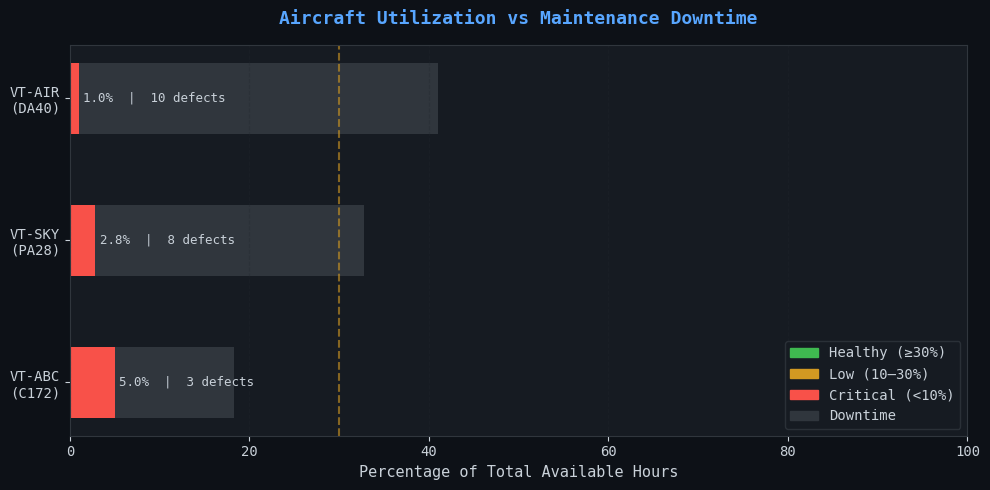

✅ Saved → charts/aircraft_utilization.png


In [25]:
# ── Chart 1: Aircraft Utilization
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d1117')

colors = [PALETTE['danger'] if u < 10 else (PALETTE['warning'] if u < 30 else PALETTE['success'])
          for u in aircraft_util['utilization_pct']]

bars = ax.barh(
    aircraft_util['registration'] + '\n(' + aircraft_util['type'] + ')',
    aircraft_util['utilization_pct'],
    color=colors, edgecolor='none', height=0.5
)

# Downtime overlay
ax.barh(
    aircraft_util['registration'] + '\n(' + aircraft_util['type'] + ')',
    aircraft_util['downtime_pct'],
    left=aircraft_util['utilization_pct'],
    color='#30363d', edgecolor='none', height=0.5,
    label='Downtime %'
)

for bar, row in zip(bars, aircraft_util.itertuples()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row.utilization_pct:.1f}%  |  {row.defect_count} defects",
            va='center', color='#c9d1d9', fontsize=9)

ax.set_xlabel("Percentage of Total Available Hours")
ax.set_title("Aircraft Utilization vs Maintenance Downtime", pad=15, fontweight='bold', color='#58a6ff')
ax.axvline(x=30, color=PALETTE['warning'], linestyle='--', alpha=0.6, label='30% threshold')
ax.set_xlim(0, 100)

patches = [
    mpatches.Patch(color=PALETTE['success'], label='Healthy (≥30%)'),
    mpatches.Patch(color=PALETTE['warning'], label='Low (10–30%)'),
    mpatches.Patch(color=PALETTE['danger'],  label='Critical (<10%)'),
    mpatches.Patch(color='#30363d',          label='Downtime'),
]
ax.legend(handles=patches, loc='lower right', facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/aircraft_utilization.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved → charts/aircraft_utilization.png")


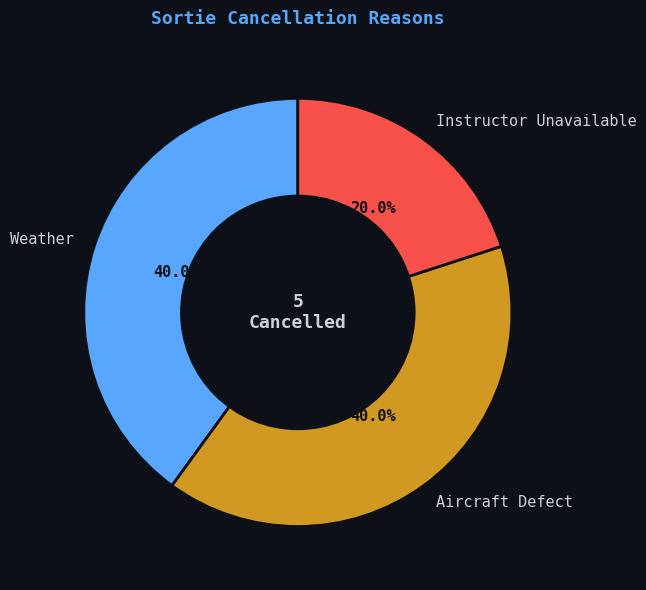

✅ Saved → charts/cancellation_reasons.png


In [26]:
# ── Chart 2: Cancellation Reasons
cancel_data = sorties[sorties['status']=='cancelled']['cancel_reason'].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0d1117')

pie_colors = [PALETTE['primary'], PALETTE['warning'], PALETTE['danger'], PALETTE['accent']]
wedges, texts, autotexts = ax.pie(
    cancel_data.values,
    labels=cancel_data.index,
    colors=pie_colors[:len(cancel_data)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2},
    textprops={'color': '#c9d1d9', 'fontsize': 11},
)
for at in autotexts:
    at.set_color('#0d1117')
    at.set_fontweight('bold')

centre_circle = plt.Circle((0,0), 0.55, fc='#0d1117')
ax.add_artist(centre_circle)

ax.text(0, 0, f"{cancelled_n}\nCancelled", ha='center', va='center',
        color='#c9d1d9', fontsize=13, fontweight='bold')

ax.set_title("Sortie Cancellation Reasons", pad=15, fontweight='bold', color='#58a6ff')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/cancellation_reasons.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved → charts/cancellation_reasons.png")


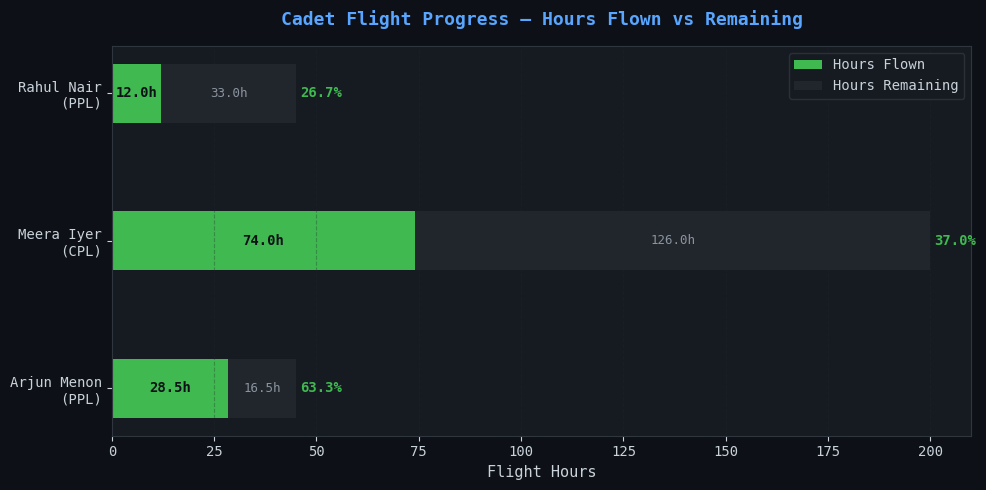

✅ Saved → charts/cadet_progress.png


In [27]:
# ── Chart 3: Cadet Flight Progress
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d1117')

cadet_names = progress['name'] + '\n(' + progress['course'] + ')'
flown   = progress['total_flown_hours'].values
remain  = progress['remaining_hours'].values

p1 = ax.barh(cadet_names, flown,  color=PALETTE['success'], label='Hours Flown',     height=0.4)
p2 = ax.barh(cadet_names, remain, left=flown, color='#21262d', label='Hours Remaining', height=0.4)

for i, (f, r, pct) in enumerate(zip(flown, remain, progress['flight_progress_pct'])):
    ax.text(f/2, i, f"{f}h", ha='center', va='center', color='#0d1117', fontweight='bold', fontsize=10)
    ax.text(f + r/2, i, f"{r}h", ha='center', va='center', color=PALETTE['muted'], fontsize=9)
    ax.text(f + r + 1, i, f"{pct:.1f}%", ha='left', va='center', color=PALETTE['success'], fontweight='bold')

ax.set_xlabel("Flight Hours")
ax.set_title("Cadet Flight Progress — Hours Flown vs Remaining", pad=15, fontweight='bold', color='#58a6ff')
ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/cadet_progress.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved → charts/cadet_progress.png")


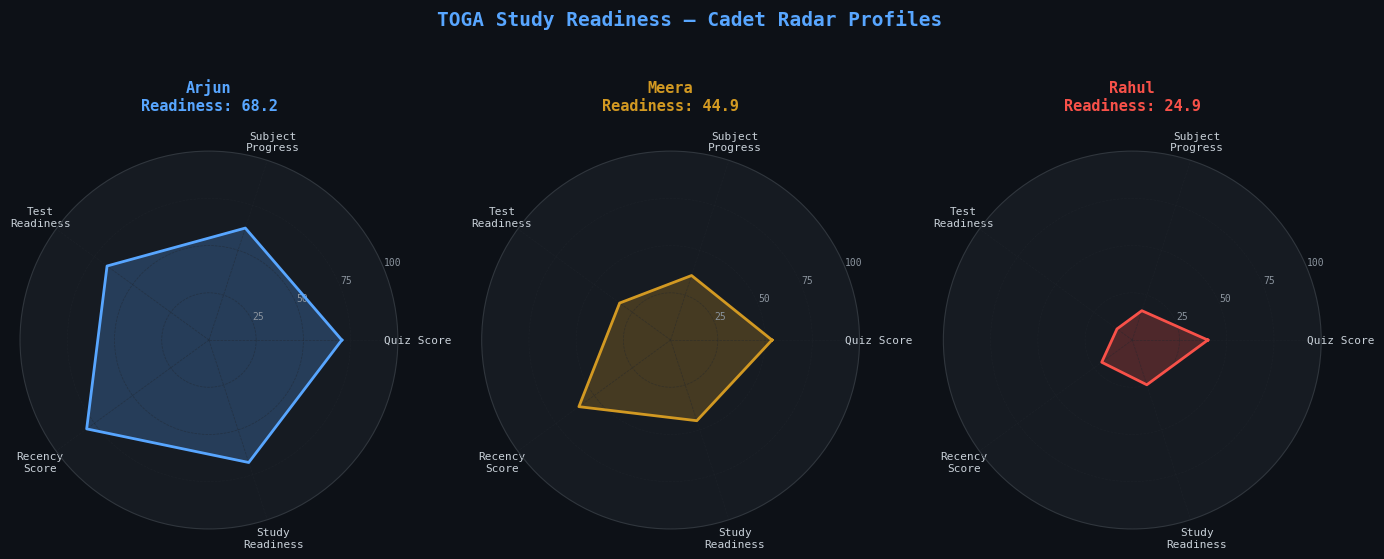

✅ Saved → charts/study_readiness.png


In [28]:
# ── Chart 4: TOGA Study Readiness (Radar/Spider Chart)
from matplotlib.patches import FancyArrowPatch
import matplotlib.path as mpath

study_display = cadet_study.merge(cadets[['cadet_id','name']], on='cadet_id')

categories = ['Quiz Score', 'Subject\nProgress', 'Test\nReadiness', 'Recency\nScore', 'Study\nReadiness']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, len(study_display), figsize=(14, 6),
                          subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0d1117')

cadet_colors = [PALETTE['primary'], PALETTE['warning'], PALETTE['danger']]

for idx, (ax, (_, row)) in enumerate(zip(axes, study_display.iterrows())):
    values = [
        row['avg_quiz_score'],
        row['avg_subject_progress'],
        row['avg_test_readiness'],
        row['avg_recency_score'],
        row['study_readiness_score'],
    ]
    values += values[:1]
    color = cadet_colors[idx % len(cadet_colors)]

    ax.set_facecolor('#161b22')
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=8, color='#c9d1d9')
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(['25','50','75','100'], color='#8b949e', size=7)
    ax.grid(color='#21262d', linewidth=0.5)
    ax.spines['polar'].set_color('#30363d')

    level = study_display.merge(cadet_study, on='cadet_id').iloc[idx]['study_risk_level'] if False else (
        '🟢 Ready' if row['study_readiness_score'] >= 70
        else ('🟡 Needs Attention' if row['study_readiness_score'] >= 50
        else '🔴 At Risk')
    )
    ax.set_title(
        f"{row['name'].split()[0]}\nReadiness: {row['study_readiness_score']:.1f}",
        pad=15, color=color, fontweight='bold', size=11
    )

fig.suptitle("TOGA Study Readiness — Cadet Radar Profiles",
             y=1.02, fontsize=14, fontweight='bold', color='#58a6ff')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/study_readiness.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved → charts/study_readiness.png")


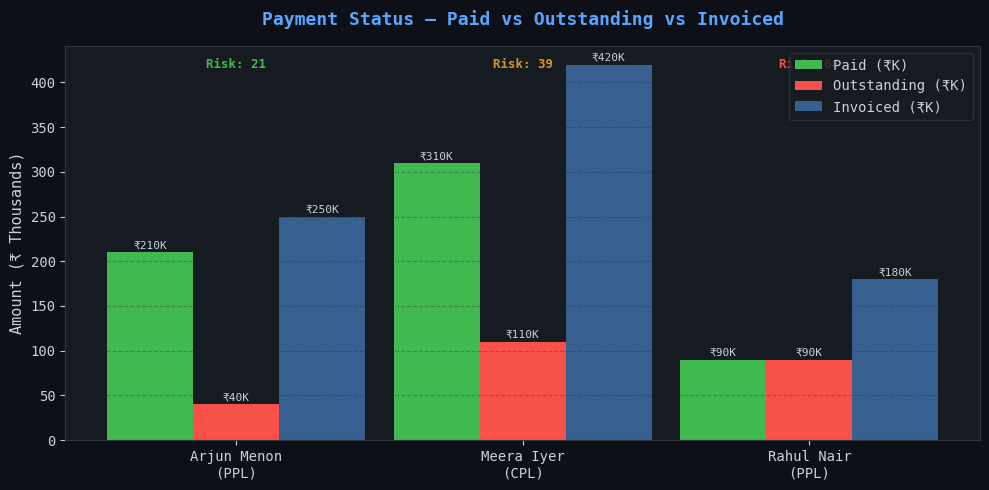

✅ Saved → charts/payment_risk.png


In [29]:
# ── Chart 5: Outstanding Payment Risk
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d1117')

x = np.arange(len(fin))
width = 0.3

b1 = ax.bar(x - width, fin['paid_amount']/1000,      width, label='Paid (₹K)',        color=PALETTE['success'], edgecolor='none')
b2 = ax.bar(x,          fin['outstanding_amount']/1000, width, label='Outstanding (₹K)', color=PALETTE['danger'],  edgecolor='none')
b3 = ax.bar(x + width,  fin['invoiced_amount']/1000,   width, label='Invoiced (₹K)',    color=PALETTE['primary'], edgecolor='none', alpha=0.5)

for bar in [b1, b2, b3]:
    for rect in bar:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, h + 2,
                f'₹{h:.0f}K', ha='center', va='bottom', fontsize=8, color='#c9d1d9')

ax.set_xticks(x)
ax.set_xticklabels(fin['name'] + '\n(' + fin['course'] + ')', fontsize=10)
ax.set_ylabel("Amount (₹ Thousands)")
ax.set_title("Payment Status — Paid vs Outstanding vs Invoiced", pad=15, fontweight='bold', color='#58a6ff')
ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(axis='y', alpha=0.3)

# Risk score annotation
for i, (_, row) in enumerate(fin.iterrows()):
    color = PALETTE['danger'] if row['payment_risk_level'].startswith('🔴') else (
            PALETTE['warning'] if row['payment_risk_level'].startswith('🟡') else PALETTE['success'])
    ax.text(i, ax.get_ylim()[1] * 0.97,
            f"Risk: {row['payment_risk_score']:.0f}",
            ha='center', va='top', color=color, fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/payment_risk.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved → charts/payment_risk.png")


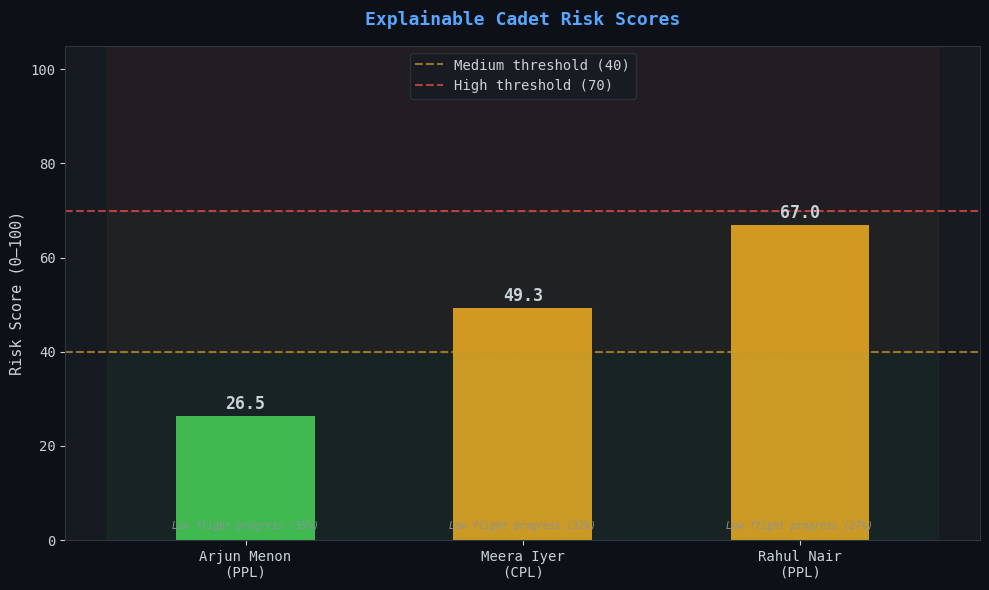

✅ Saved → charts/cadet_risk_scores.png


In [30]:
# ── Chart 6: Cadet Risk Score Bar
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0d1117')

risk_colors = {
    'Low':    PALETTE['success'],
    'Medium': PALETTE['warning'],
    'High':   PALETTE['danger'],
}
bar_colors = [risk_colors[lvl] for lvl in risk_df['risk_level']]

bars = ax.bar(
    risk_df['name'] + '\n(' + risk_df['course'] + ')',
    risk_df['risk_score'],
    color=bar_colors, edgecolor='none', width=0.5
)

# Score labels on bars
for bar, score in zip(bars, risk_df['risk_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{score:.1f}', ha='center', va='bottom', fontweight='bold',
            color='#c9d1d9', fontsize=12)

# Risk zone lines
ax.axhline(y=40, color=PALETTE['warning'], linestyle='--', alpha=0.7, linewidth=1.5, label='Medium threshold (40)')
ax.axhline(y=70, color=PALETTE['danger'],  linestyle='--', alpha=0.7, linewidth=1.5, label='High threshold (70)')
ax.fill_between([-0.5, 2.5], 0,  40, color=PALETTE['success'], alpha=0.05)
ax.fill_between([-0.5, 2.5], 40, 70, color=PALETTE['warning'], alpha=0.05)
ax.fill_between([-0.5, 2.5], 70, 105, color=PALETTE['danger'],  alpha=0.05)

ax.set_ylim(0, 105)
ax.set_ylabel("Risk Score (0–100)")
ax.set_title("Explainable Cadet Risk Scores", pad=15, fontweight='bold', color='#58a6ff')
ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')

# Main reason annotation
for i, (_, row) in enumerate(risk_df.iterrows()):
    top = row['main_reasons'].split(' | ')[0]
    ax.text(i, 2, top, ha='center', va='bottom', fontsize=7, color='#8b949e', style='italic')

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/cadet_risk_scores.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved → charts/cadet_risk_scores.png")


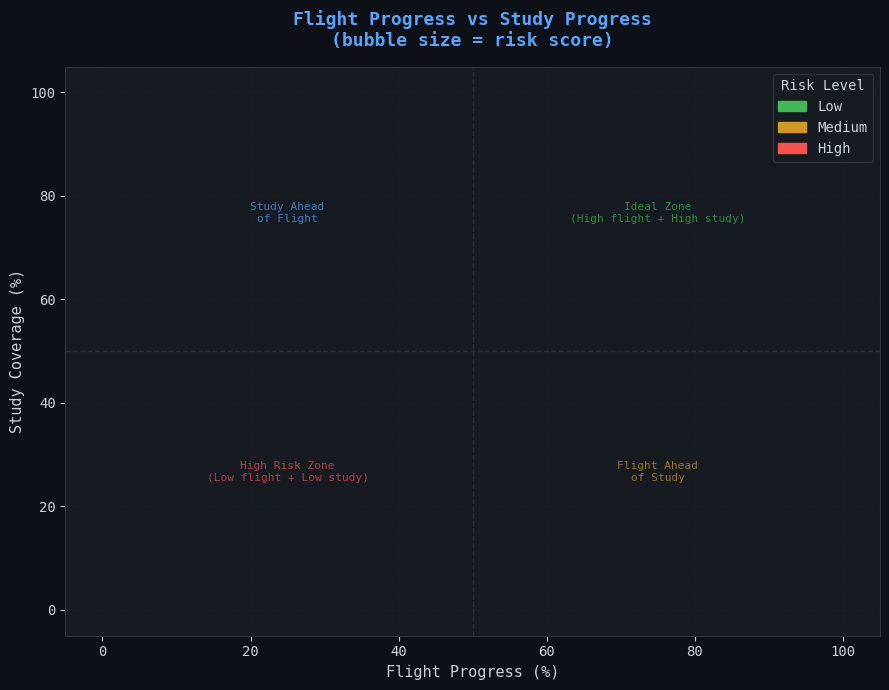

✅ Saved → charts/flight_vs_study_progress.png


In [31]:
# ── Chart 7: Flight Progress vs Study Progress Scatter
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0d1117')

scatter_df = (
    progress[['cadet_id','name','flight_progress_pct']]
    .merge(cadet_study[['cadet_id','avg_subject_progress','study_readiness_score','avg_quiz_score']], on='cadet_id')
    .merge(risk_df[['cadet_id','risk_level','risk_score']], on='cadet_id')
)

risk_color_map = {'Low': PALETTE['success'], 'Medium': PALETTE['warning'], 'High': PALETTE['danger']}
point_colors   = [risk_color_map[r] for r in scatter_df['risk_level']]
point_sizes    = scatter_df['risk_score'] * 5 + 100

sc = ax.scatter(
    scatter_df['flight_progress_pct'] * 100,
    scatter_df['avg_subject_progress'],
    c=point_colors,
    s=point_sizes,
    edgecolors='#30363d',
    linewidths=1.5,
    alpha=0.9,
    zorder=5
)

# Cadet name labels
for _, row in scatter_df.iterrows():
    ax.annotate(
        f"  {row['name'].split()[0]}\n  Score: {row['risk_score']:.0f}",
        xy=(row['flight_progress_pct']*100, row['avg_subject_progress']),
        fontsize=9, color='#c9d1d9',
        xytext=(8, 8), textcoords='offset points'
    )

# Quadrant lines
ax.axvline(x=50, color='#30363d', linestyle='--', alpha=0.7, linewidth=1)
ax.axhline(y=50, color='#30363d', linestyle='--', alpha=0.7, linewidth=1)

# Quadrant labels
ax.text(75, 75, "Ideal Zone\n(High flight + High study)", ha='center', color=PALETTE['success'], fontsize=8, alpha=0.7)
ax.text(25, 25, "High Risk Zone\n(Low flight + Low study)", ha='center', color=PALETTE['danger'],  fontsize=8, alpha=0.7)
ax.text(75, 25, "Flight Ahead\nof Study",  ha='center', color=PALETTE['warning'], fontsize=8, alpha=0.7)
ax.text(25, 75, "Study Ahead\nof Flight",  ha='center', color=PALETTE['primary'], fontsize=8, alpha=0.7)

ax.set_xlabel("Flight Progress (%)")
ax.set_ylabel("Study Coverage (%)")
ax.set_title("Flight Progress vs Study Progress\n(bubble size = risk score)", pad=15, fontweight='bold', color='#58a6ff')
ax.set_xlim(-5, 105)
ax.set_ylim(-5, 105)
ax.grid(alpha=0.2)

patches = [mpatches.Patch(color=c, label=l) for l, c in risk_color_map.items()]
ax.legend(handles=patches, title="Risk Level", facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/flight_vs_study_progress.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved → charts/flight_vs_study_progress.png")


---
## Section 8 — Final Exports & Summary


In [32]:
# ── Final Output Summary
print("=" * 60)
print("  AIRMAN ASSESSMENT — OUTPUTS GENERATED")
print("=" * 60)

print("\n📂 data/")
print("   ✅ cleaned_outputs.csv   — Cleaned sorties with computed flight durations")
print("   ✅ risk_scores.csv       — Cadet risk scores with reasons")
print("   ✅ data_quality_issues.csv — All data validation issues found")

print("\n📊 charts/")
charts = [
    "aircraft_utilization.png",
    "cancellation_reasons.png",
    "cadet_progress.png",
    "study_readiness.png",
    "payment_risk.png",
    "cadet_risk_scores.png",
    "flight_vs_study_progress.png"
]
for c in charts:
    import os
    path = f'{CHARTS_DIR}/{c}'
    status = "✅" if os.path.exists(path) else "❌"
    print(f"   {status} {c}")

print("\n📋 KEY METRICS SUMMARY")
print(f"   Sorties    : {total} total | {completed_n} completed | {cancelled_n} cancelled")
print(f"   Completion : {completion_rate:.1f}% | Avg Delay: {avg_delay_completed:.1f} min")
print(f"   Aircraft   : {len(aircraft)} | Avg Utilization: {aircraft_util['utilization_pct'].mean():.1f}%")
print(f"   Revenue    : ₹{fin['invoiced_amount'].sum():,.0f} invoiced | ₹{fin['outstanding_amount'].sum():,.0f} outstanding")
print(f"   Risk Scores:")
for _, row in risk_df[['name','risk_score','risk_level']].iterrows():
    print(f"     {row['name']:15s}: {row['risk_score']:.1f} [{row['risk_level']}]")

print("\n✅ Analysis complete. See reports/ folder for written reports.")


  AIRMAN ASSESSMENT — OUTPUTS GENERATED

📂 data/
   ✅ cleaned_outputs.csv   — Cleaned sorties with computed flight durations
   ✅ risk_scores.csv       — Cadet risk scores with reasons
   ✅ data_quality_issues.csv — All data validation issues found

📊 charts/
   ✅ aircraft_utilization.png
   ✅ cancellation_reasons.png
   ✅ cadet_progress.png
   ✅ study_readiness.png
   ✅ payment_risk.png
   ✅ cadet_risk_scores.png
   ✅ flight_vs_study_progress.png

📋 KEY METRICS SUMMARY
   Sorties    : 15 total | 10 completed | 5 cancelled
   Completion : 66.7% | Avg Delay: 16.0 min
   Aircraft   : 3 | Avg Utilization: 2.9%
   Revenue    : ₹850,000 invoiced | ₹240,000 outstanding
   Risk Scores:
     Arjun Menon    : 26.5 [Low]
     Meera Iyer     : 49.3 [Medium]
     Rahul Nair     : 67.0 [Medium]

✅ Analysis complete. See reports/ folder for written reports.
